# Machine Learning on Microscopy data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def synthetic_data(m=300):
    Xh = np.vstack([np.random.randn(m//3,2) + np.array([1,0]),
                    np.random.randn(m//3,2) + np.array([-3,-1]), 
                    np.random.randn(m//3,2) + np.array([3,-3])])
    Y = np.vstack([np.ones((m//3,1)) @ np.array([[1,0,0]]),
                   np.ones((m//3,1)) @ np.array([[0,1,0]]),
                   np.ones((m//3,1)) @ np.array([[0,0,1]])])
    return Xh, Y

def extend_X(Xh):
    X = np.ones((Xh.size//Xh.shape[-1], Xh.shape[-1]+1))
    X[:, 1:] = Xh
    return X


Softmax feature function

In [38]:
def softmax(W):
    N,M = np.shape(W)
    exp = (np.exp(W))
    P = exp / np.sum(exp, axis=1).reshape(N,1)
    return P


Prediction rule

In [39]:
def h(Xh,Theta):    
    x = extend_X(Xh)
    W = np.dot(x,Theta)
    return softmax(W)

Test prediction rule:

In [40]:

def test_h1():
    Xh = np.array([[1]])
    Theta = np.array([[0.5], [1]])
    assert np.abs(h(Xh, Theta) - 1)<1e-7, "test_h1 detected a wrong h value"

def test_h2():
    Xh = np.array([[-1]])
    Theta = np.array([[1,0,0], [1,0,0]])
    assert np.linalg.norm(h(Xh, Theta) - np.ones((1,3))/3)<1e-7, "test_h2 detected a wrong h value"


def test_h3():
    Xh = np.array([[1,0], [0,1]])
    Theta = np.array([[1,0], [0,1], [0,1]])
    assert np.linalg.norm(h(Xh, Theta) - np.ones((2,2))/2)<1e-7, "test_h3 detected a wrong h value"

test_h1()
test_h2()
test_h3()



Question 3: Loss function

In [41]:
def loss(Xh, Theta, Y):
    M, K = np.shape(Y)
    hval = h(Xh, Theta)
    return -(1/M) * np.sum((Y*np.log(hval)))

Test Loss function:

In [42]:
def test_loss1():
    Xh = np.array([[1]])
    Theta = np.array([[0.5], [1]])
    Y = np.array([[1]])
    assert np.abs(loss(Xh, Theta, Y))<1e-7, "test_loss1 detected a wrong loss value"

def test_loss2():
    Xh = np.array([[-1]])
    Theta = np.array([[1,0,0], [1,0,0]])
    Y = np.array([[0.5,0,0.5]])
    assert np.abs(loss(Xh, Theta, Y) - np.log(3))<1e-7, "test_loss2 detected a wrong loss value"
def test_loss3():
    Xh = np.array([[1,0], [0,1]])
    Theta = np.array([[1,0], [0,1], [0,1]])
    Y = np.array([[0,1], [0.25,0.75]])
    assert np.abs(loss(Xh, Theta, Y) + np.log(0.5))<1e-7, "test_loss3 detected a wrong loss value"

test_loss1()
test_loss2()
test_loss3()

Q4: Gradient of the loss function

In [43]:
def grad_loss(Xh, Theta, Y):
    X = extend_X(Xh)
    M, N = X.shape
    K = Theta.shape[1]
    H = h(Xh, Theta)
    G = np.dot(X.T,H-Y)     
    return G / M


Test Gradient loss:

In [44]:

def test_grad1():
    Xh = np.array([[1]])
    Theta = np.array([[0.5], [1]])
    Y = np.array([[1]])
    assert np.linalg.norm(grad_loss(Xh, Theta, Y))<1e-7, "test_grad1 detected a wrong gradient value"

test_grad1()


def test_grad2():
    Xh = np.array([[-1]])
    Theta = np.array([[1,0,0], [1,0,0]])
    Y = np.array([[0.5,0,0.5]])
    G_exact = np.array([[-1/6,1/3,-1/6], [1/6,-1/3,1/6]])
    assert np.linalg.norm(grad_loss(Xh, Theta, Y) - G_exact)<1e-7, "test_grad2 detected a wrong gradient value"

test_grad2()

def test_grad3():
    Xh = np.array([[1,0], [0,1]])
    Theta = np.array([[1,0], [0,1], [0,1]])
    Y = np.array([[0,1], [0.25,0.75]])
    G_exact = np.array([[3/8,-3/8], [1/4,-1/4], [1/8,-1/8]])
    assert np.linalg.norm(grad_loss(Xh, Theta, Y) - G_exact)<1e-7, "test_grad3 detected a wrong gradient value"


test_grad3()

Q5: Data splitting

In [45]:
def data_split(X,Y,Mtest=50):
    M = X.shape[0]
    I = np.arange(0,M)
    np.random.shuffle(I)
    Itrain = I[:Mtest]
    Itest = I[Mtest:]
    Xtrain = X[Itrain]
    Ytrain = Y[Itrain]
    Xtest = X[Itest]
    Ytest = Y[Itest]
    return Xtrain, Ytrain, Xtest, Ytest
#test
X = np.array([1,2,4,3,2,3])
Y = np.array([0,0,1,1,0,1])
print(data_split(X,Y,2))

(array([3, 3]), array([1, 1]), array([1, 4, 2, 2]), array([0, 1, 0, 0]))


Q6: Gradient descent

In [46]:
def gd(Xtrain, Ytrain, Xtest, Ytest, Theta0, t = 1, p = 100, q=0.99, S = 1000):
    theta_s = Theta0
    test_losses = []
    best_theta = theta_s
    best_loss = loss(Xtest, theta_s, Ytest)
    s_star = 0
    for s in range(S):
        test_losses.append(loss(Xtest, theta_s, Ytest))
        if (s >= p) and (test_losses[s] > q*test_losses[s-p]):
            break
        if test_losses[s] < best_loss:
            best_theta = theta_s
            best_loss = test_losses[s]
            s_star = s
        G = grad_loss(Xtrain, theta_s, Ytrain)
        theta_s = theta_s - t*G
        
    return best_theta, s_star, test_losses

Q7: Testing GD on synthetic data

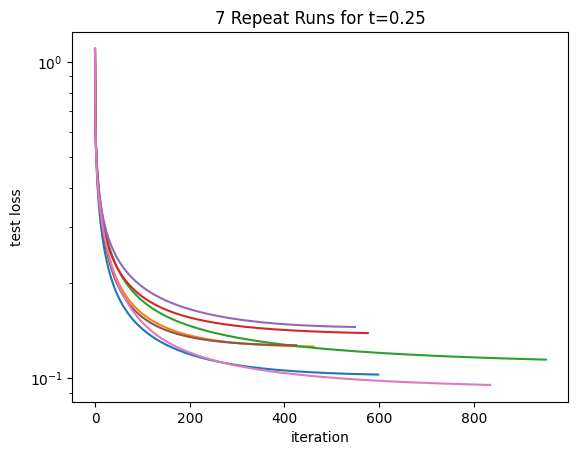

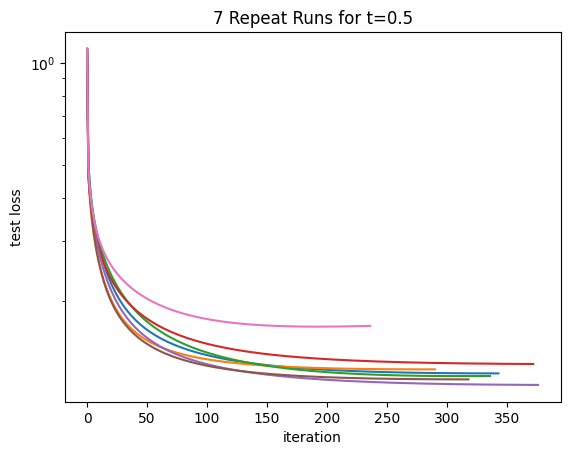

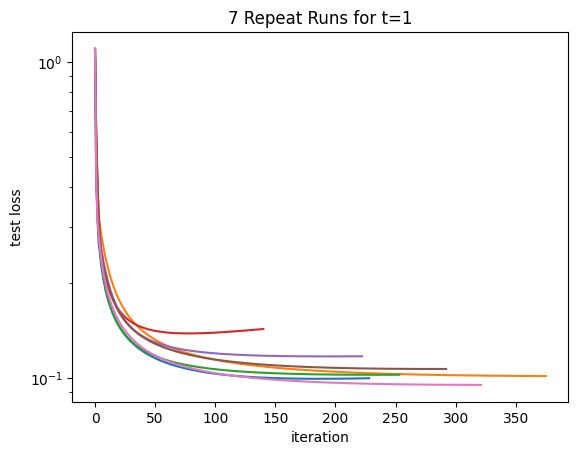

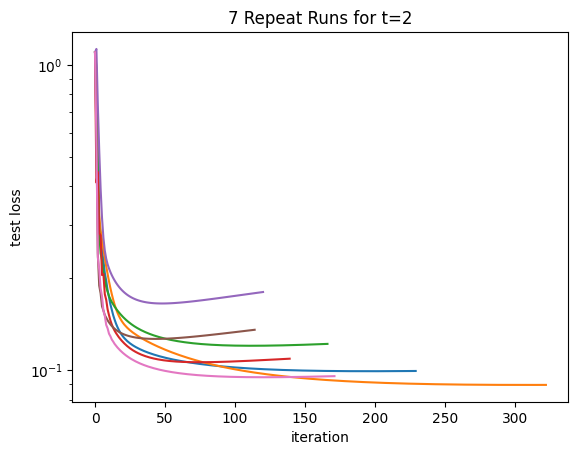

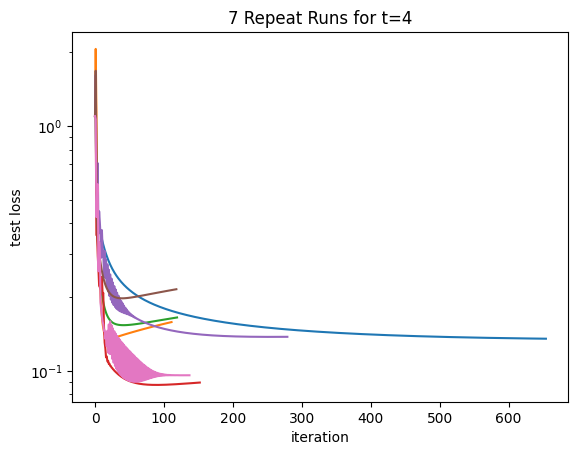

In [47]:
Xh, Y = synthetic_data()
results = {} #save the results for different t values

for j in [1/4, 1/2, 1, 2, 4]:
    
    smallest_test_loss = np.inf
    Theta0 = np.zeros((3, 3))
    
    plt.figure()
    last_iters = []
    best_iters = []
    for i in range(7):
        Xtrain, Ytrain, Xtest, Ytest = data_split(Xh, Y)
        Theta, s_star, test_losses = gd(Xtrain, Ytrain, Xtest, Ytest, Theta0, t=j)
        last_iters.append(len(test_losses)) # make a list of stopping time
        best_iters.append(s_star) # make a list of the iteration with the best test loss
    
        if min(test_losses) < smallest_test_loss:
            smallest_test_loss = min(test_losses) # find the smallest test loss
        plt.plot(test_losses)
    results[j] = {
        "average_last_iter": np.mean(last_iters),
        "average_best_iter": np.mean(best_iters),
        "min_last_iter": np.min(last_iters),
        "max_last_iter": np.max(last_iters),
        "losses": test_losses,
        "Theta_star": Theta
    }
    #plot
    plt.semilogy()
    plt.title(f"7 Repeat Runs for t={j}")
    plt.xlabel("iteration")
    plt.ylabel("test loss")


For t = 1/2 (or whichever is the largest such that all runs monotoncally decrease), show the results:

In [ ]:

print("smallest test loss over all runs: ", smallest_test_loss)
best_t = 0.5 #this can be changed based on the above graphs
last_mean = results[best_t]["average_last_iter"]
best_mean = results[best_t]["average_best_iter"]
last_min = results[best_t]["min_last_iter"]
last_max = results[best_t]["max_last_iter"]
print(f"Average number of total iterations for 7 runs: {last_mean}")
print(f"Average of best iteration for 7 runs: {best_mean}")
print(f"Minimum total iteration for 7 runs: {last_min}")
print(f"Maximum total iteration for 7 runs: {last_max}")



smallest test loss over all runs:  0.08743956211223684
Average number of total iterations for 7 runs: 325.42857142857144
Average of best iteration for 7 runs: 313.42857142857144
Minimum total iteration for 7 runs: 237
Maximum total iteration for 7 runs: 377


Plot predictions and probabilities with the given plot_2D_data function

<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
C:\Users\luluh\AppData\Local\Temp\ipykernel_33516\1563789663.py:15: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("$\hat x_1$")
C:\Users\luluh\AppData\Local\Temp\ipykernel_33516\1563789663.py:16: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel("$\hat x_2$")


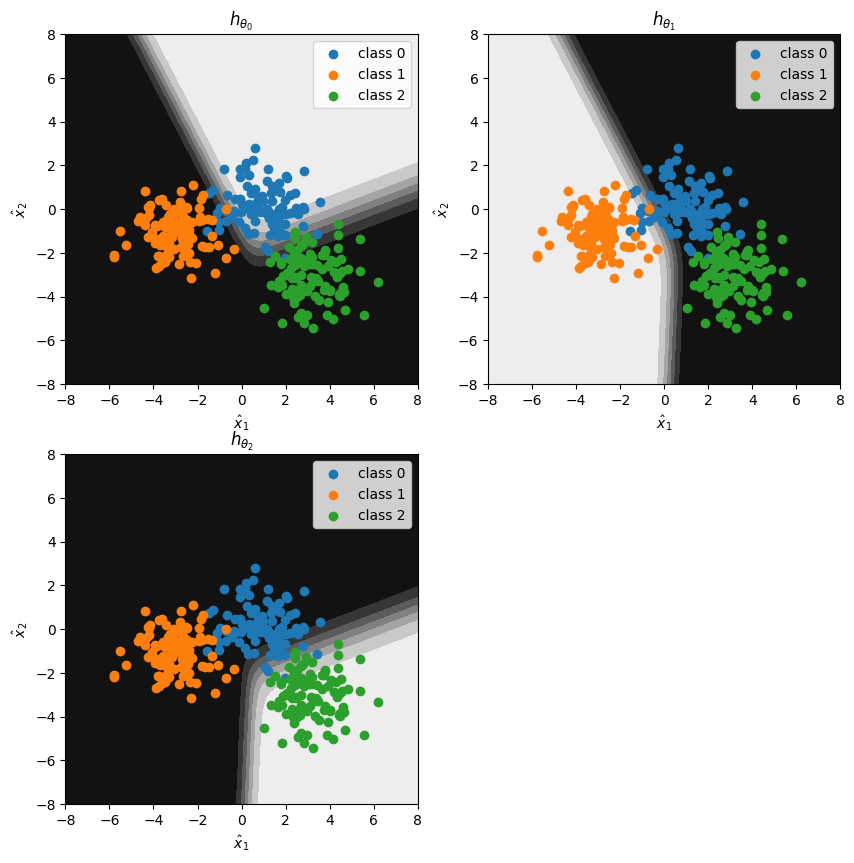

In [49]:
def plot_2D_data(Xh, Y, Theta=0):
    X1,X2 = np.meshgrid(np.linspace(-8,8,99), np.linspace(-8,8,99))
    Xgrid = np.vstack([X1.ravel(), X2.ravel()]).T
    try:
        Ypred = h(Xgrid, Theta)
    except:
        Ypred = 0.5*np.ones((Xgrid.shape[0], Y.shape[1]))
    plt.figure(figsize=(10,10))
    for k in range(Y.shape[1]):
        plt.subplot(2, int(np.ceil(Y.shape[1]/2)), k+1)
        plt.contourf(X1, X2, Ypred[:,k].reshape(X1.shape), cmap='gray')
        for j in range(Y.shape[1]):
            plt.scatter(Xh[np.argmax(Y, axis=1)==j, 0], Xh[np.argmax(Y, axis=1)==j, 1], label=f"class {j}")
        plt.title("$h_{θ_{"+str(k)+"}}$")
        plt.xlabel("$\hat x_1$")
        plt.ylabel("$\hat x_2$")
        plt.legend()
    
    plt.show()
plot_2D_data(Xh, Y, Theta = results[best_t]["Theta_star"])


Q7: Another test of accuracy by using a confusion matrix

In [50]:
from sklearn.metrics import confusion_matrix
theta_star = results[best_t]["Theta_star"]
Yprob = h(Xh, theta_star)
Ypred = np.argmax(Yprob, axis=1)
Ytrue = np.argmax(Y, axis=1)
con_mat = confusion_matrix(Ytrue, Ypred)
print(con_mat)
print("Class 1 omission error: ", (con_mat[0,1] + con_mat[0,2])/np.sum(con_mat[0,:]))    
print("Class 2 omission error: ", (con_mat[1,0] + con_mat[1,2])/np.sum(con_mat[1,:]))
print("Class 3 omission error: ", (con_mat[2,0] + con_mat[2,1])/np.sum(con_mat[2,:]))

print("Class 1 commission error: ", (con_mat[1,0] + con_mat[2,0])/np.sum(con_mat[:,0]))
print("Class 2 commission error: ", (con_mat[0,1] + con_mat[2,1])/np.sum(con_mat[:,1]))
print("Class 3 commission error: ", (con_mat[0,2] + con_mat[1,2])/np.sum(con_mat[:,2]))

print("Overall error rate: ", (con_mat[0,1] + con_mat[0,2] + con_mat[1,0] + con_mat[1,2] + con_mat[2,0] + con_mat[2,1])/np.sum(con_mat))
print("Accuracy: ", 1-(con_mat[0,1] + con_mat[0,2] + con_mat[1,0] + con_mat[1,2] + con_mat[2,0] + con_mat[2,1])/np.sum(con_mat))

[[ 86  10   4]
 [  0 100   0]
 [  1   0  99]]
Class 1 omission error:  0.14
Class 2 omission error:  0.0
Class 3 omission error:  0.01
Class 1 commission error:  0.011494252873563218
Class 2 commission error:  0.09090909090909091
Class 3 commission error:  0.038834951456310676
Overall error rate:  0.05
Accuracy:  0.95


Q8: Loading and PCA of spectromicroscopy data

In [51]:
# Load the data
data = np.load('CW.npz')
Xh = data['Xh']  
Y = data['Y']    
Xhnew = data['Xhnew'] 
r = 3
#Do PCA manually (I found this gave better results than using sklearn due to centering and normalising)
cov = Xh.T@Xh
eigvals, eigvecs = np.linalg.eigh(cov)
idx = eigvals.argsort()[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]
U = eigvecs[:, :r]
Zh = np.dot(Xh,U)
Zhnew = np.dot(Xhnew,U)
# Total variance
total_variance = np.sum(eigvals)

# Variance explained by each component
explained_variance_ratio = eigvals[:r] / total_variance

print(explained_variance_ratio)

[0.99421039 0.00398786 0.00178936]


Q9 Classification of spectromicroscopy data

<Figure size 640x480 with 0 Axes>

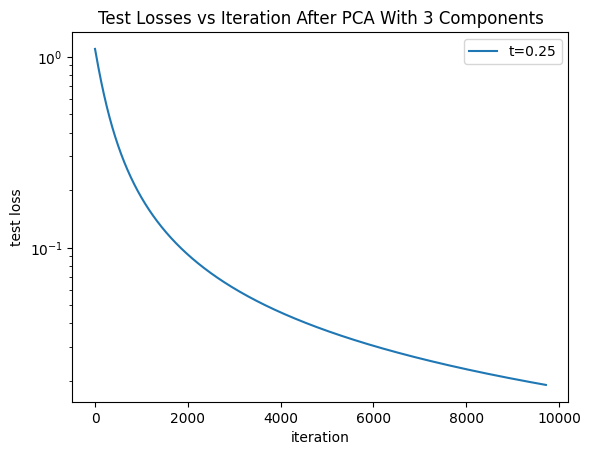

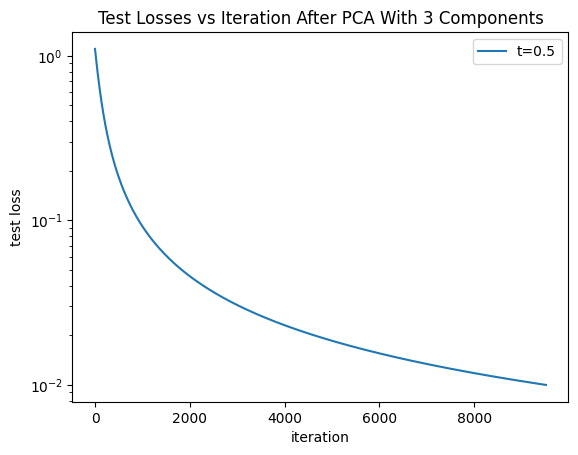

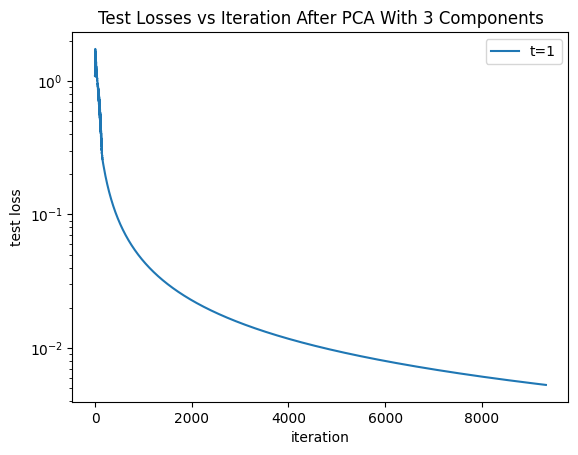

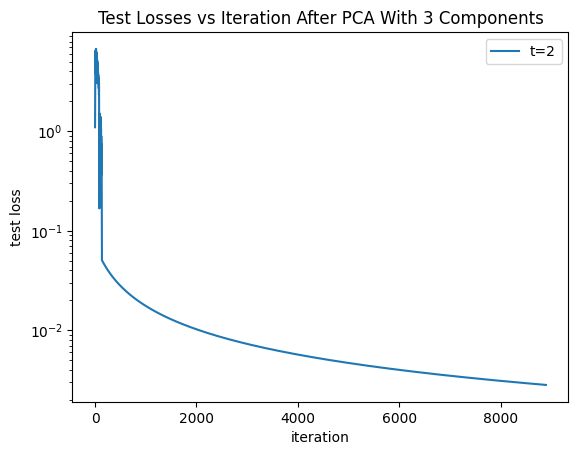

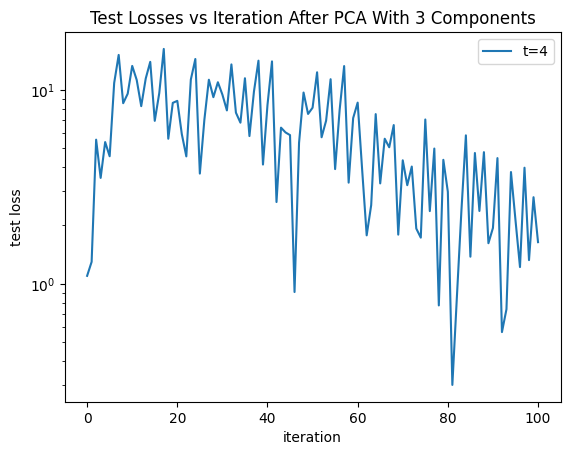

In [52]:
Ztrain, Ytrain, Ztest, Ytest = data_split(Zh,Y)


Theta0 = np.zeros((r+1,r))
plt.figure()
thetas = []
for j in [1/4, 1/2, 1, 2, 4]:
    Theta_star,s_star,test_losses = gd(Ztrain, Ytrain, Ztest, Ytest, Theta0, t=j, S = int(1e5))
    #plot the losses:
    plt.figure()
    plt.plot(test_losses, label=f"t={j}")
    plt.yscale('log')
    plt.legend()
    plt.title("Test Losses vs Iteration After PCA With 3 Components")
    plt.xlabel("iteration")
    plt.ylabel("test loss")
    thetas.append(Theta_star)




Compute probabilities and plot classification:

<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
C:\Users\luluh\AppData\Local\Temp\ipykernel_33516\1996813848.py:9: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("$\hat x_1$")
C:\Users\luluh\AppData\Local\Temp\ipykernel_33516\1996813848.py:10: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel("$\hat x_2$")


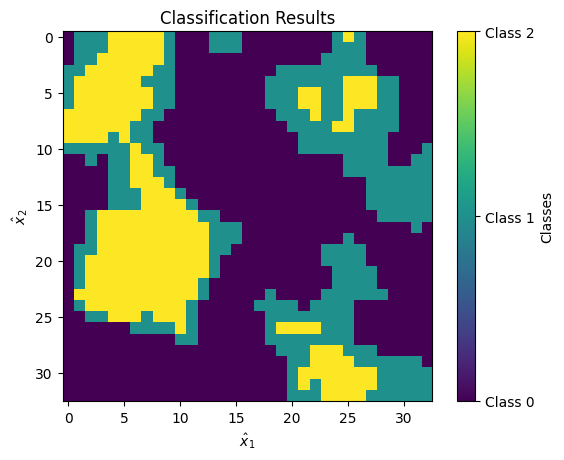

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
best_index = 1 # index of largest t with monotonic decrease, can be changed based on above graphs
Hnew = h(Zhnew, thetas[best_index])
K = np.argmax(Hnew, axis=1).reshape(33,33)
c = plt.imshow(K, cmap='viridis')
cbar = plt.colorbar(c, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['Class 0', 'Class 1', 'Class 2'])
cbar.set_label('Classes')
plt.title('Classification Results')
plt.xlabel("$\hat x_1$")
plt.ylabel("$\hat x_2$")
plt.show()
plt.figure()


Run for 'best t' to investigate reproducability:

<>:19: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
C:\Users\luluh\AppData\Local\Temp\ipykernel_33516\1103055674.py:19: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("$\hat x_1$")
C:\Users\luluh\AppData\Local\Temp\ipykernel_33516\1103055674.py:20: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel("$\hat x_2$")


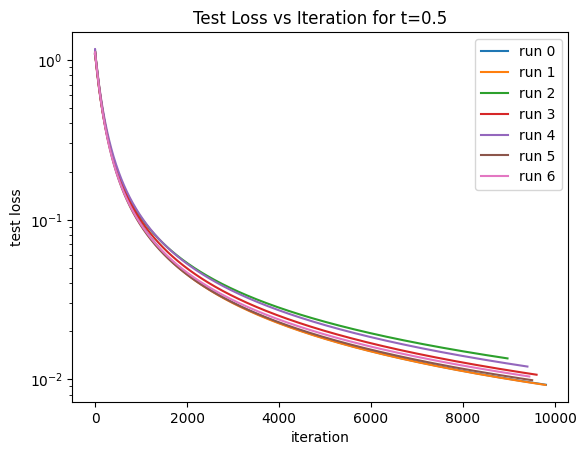

<Figure size 640x480 with 0 Axes>

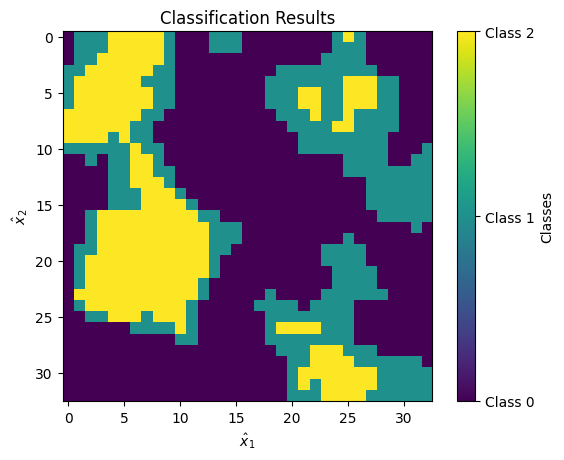

<Figure size 640x480 with 0 Axes>

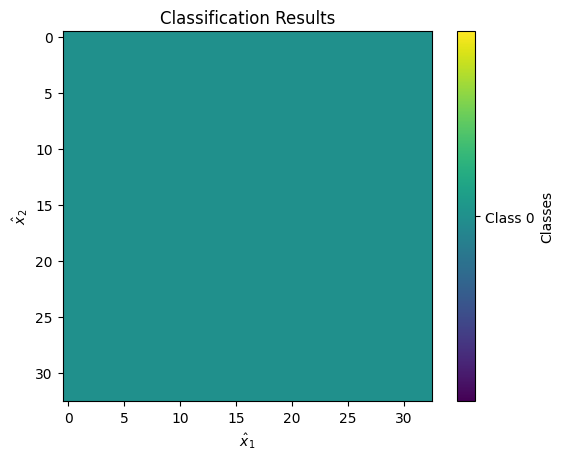

<Figure size 640x480 with 0 Axes>

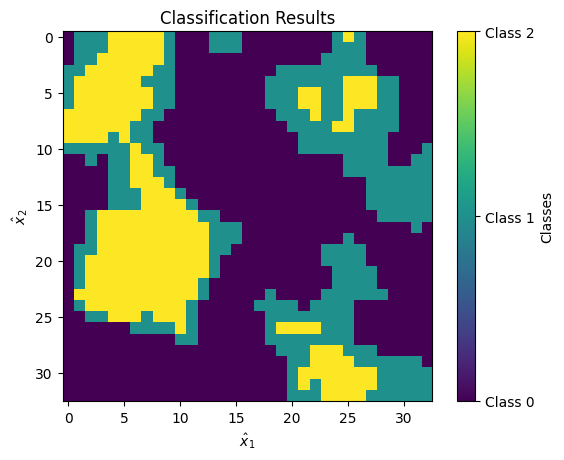

<Figure size 640x480 with 0 Axes>

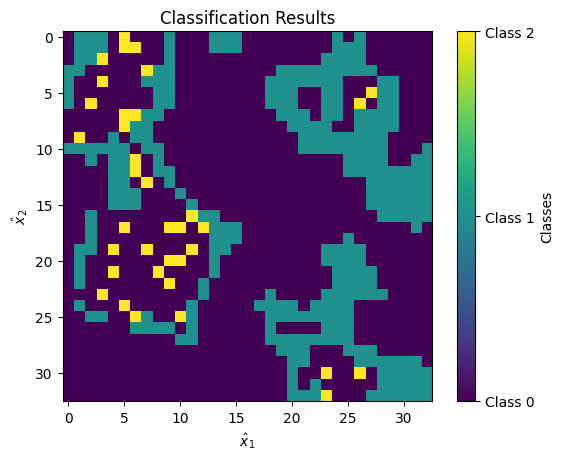

<Figure size 640x480 with 0 Axes>

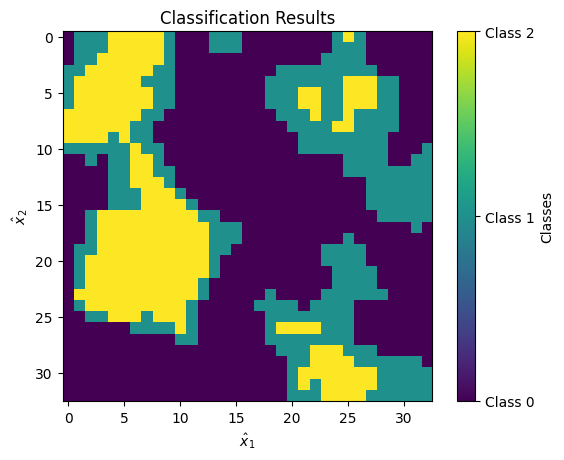

<Figure size 640x480 with 0 Axes>

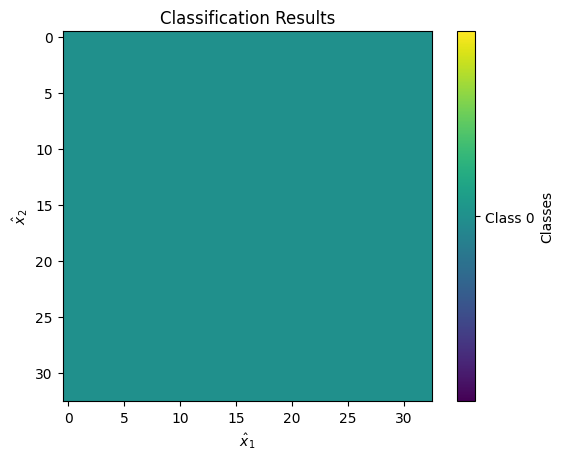

<Figure size 640x480 with 0 Axes>

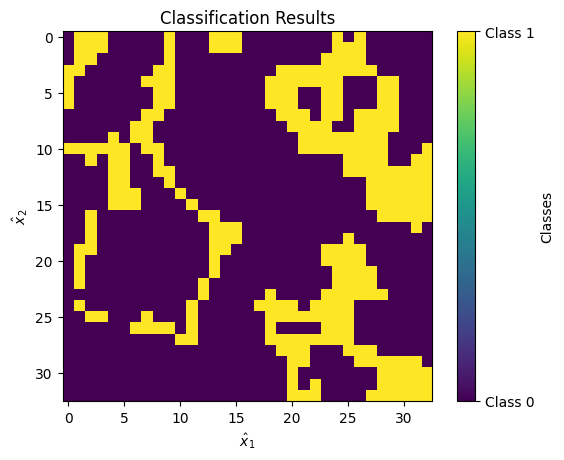

In [54]:

T = [1/4,1/2,1,2,4][best_index]
# Create two figures
fig2, ax2 = plt.subplots()
for i in range(7):
    plt.figure()
    Ztrain, Ytrain, Ztest, Ytest = data_split(Zh,Y)
    theta_star, s_star, test_losses = gd(Ztrain, Ytrain, Ztest, Ytest, Theta0, t=T, S = int(1e5))
    plt.figure()
    Hnew = h(Zhnew, theta_star)
    K = np.argmax(Hnew, axis=1).reshape(33,33)

    # Print and plot the classification results
    c = plt.imshow(K, cmap='viridis')

    cbar = plt.colorbar(c, ticks=[0, 1, 2])
    cbar.ax.set_yticklabels(['Class 0', 'Class 1', 'Class 2'])
    cbar.set_label('Classes')
    plt.title('Classification Results')
    plt.xlabel("$\hat x_1$")
    plt.ylabel("$\hat x_2$")
    
    ax2.plot(test_losses, label=f"run {i}")
    ax2.set_yscale('log')
    ax2.set_title(f"Test Loss vs Iteration for t={T}")
    ax2.set_xlabel("iteration")
    ax2.set_ylabel("test loss")
    ax2.legend()


    

